In [1]:
import pandas as pd

df = pd.read_csv(r"/content/water_potability.csv")
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [2]:
print('ph median:', df['ph'].median())

ph median: 7.036752103833548


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


,0
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0
Potability,0


In [4]:
#Handle Missing Values

df = df.fillna(df.median(numeric_only=True))

In [5]:
#Separate Features & Target

X = df.drop('Potability', axis=1)
y = df['Potability']

In [6]:
print('Before fillna:', df.isnull().sum())

Before fillna: ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


In [7]:
print(df.isnull().sum())

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


In [8]:
#Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [9]:
import numpy as np
print('Std of X_train:', np.std(X_train, axis=0))

Std of X_train: ph                    1.462505
Hardness             32.572857
Solids             8833.392696
Chloramines           1.587732
Sulfate              36.194707
Conductivity         81.174047
Organic_carbon        3.284415
Trihalomethanes      15.844278
Turbidity             0.779013
dtype: float64


In [10]:
#Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
import numpy as np
print('NaN in X_train:', np.isnan(X_train).sum())
print('Shape X_train:', X_train.shape)

NaN in X_train: 0
Shape X_train: (2620, 9)


In [12]:
#Handle Imbalance

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

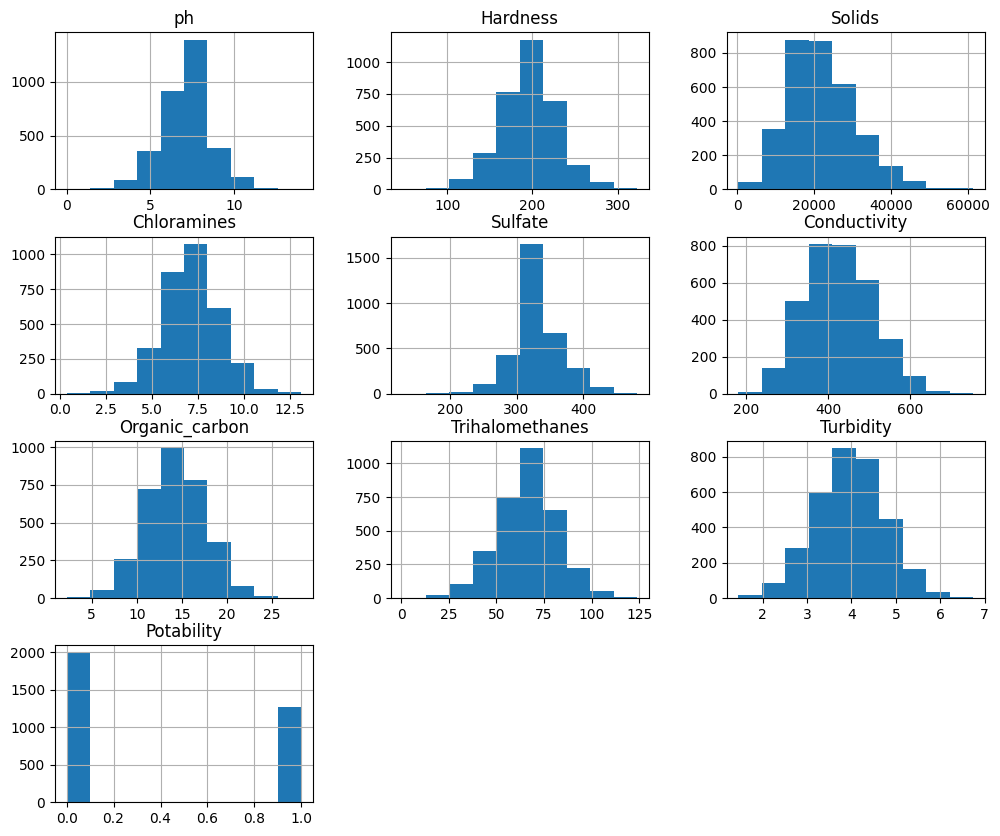

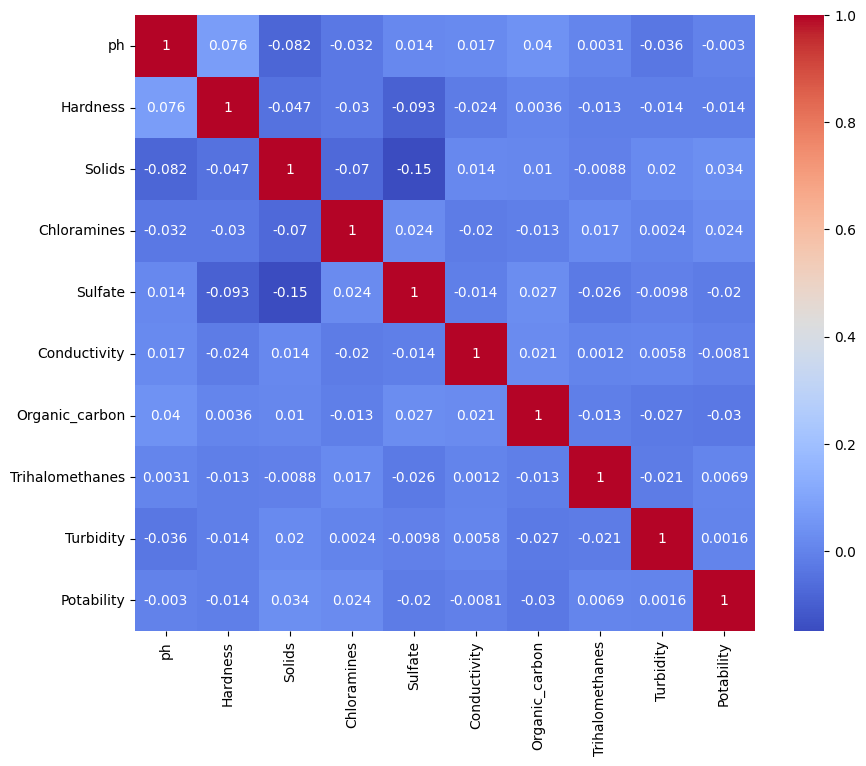

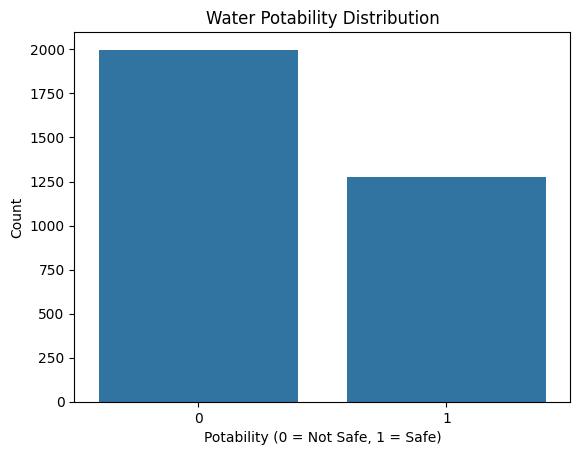

In [13]:
#EDA

import seaborn as sns
import matplotlib.pyplot as plt

# Distribution
df.hist(figsize=(12,10))
plt.show()

# Correlation
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

# NEW
sns.countplot(x='Potability', data=df)
plt.title("Water Potability Distribution")
plt.xlabel("Potability (0 = Not Safe, 1 = Safe)")
plt.ylabel("Count")
plt.show()

In [14]:
#Model Training

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression(max_iter=1000)
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [15]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

from sklearn.metrics import accuracy_score
print("SVM:", accuracy_score(y_test, svm_pred))

SVM: 0.6387195121951219


In [16]:
#Predictions

lr_pred = lr.predict(X_test)
dt_pred = dt.predict(X_test)
rf_pred = rf.predict(X_test)

In [17]:
#Accuracy

from sklearn.metrics import accuracy_score

print("LR:", accuracy_score(y_test, lr_pred))
print("DT:", accuracy_score(y_test, dt_pred))
print("RF:", accuracy_score(y_test, rf_pred))

LR: 0.5030487804878049
DT: 0.5564024390243902
RF: 0.6432926829268293


In [18]:
#Confusion Matrix

from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, lr_pred))
print(confusion_matrix(y_test, dt_pred))
print(confusion_matrix(y_test, rf_pred))

[[213 199]
 [127 117]]
[[258 154]
 [137 107]]
[[306 106]
 [128 116]]


In [19]:
#Precision, Recall, F1-score

from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))
print(classification_report(y_test, dt_pred))
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.63      0.52      0.57       412
           1       0.37      0.48      0.42       244

    accuracy                           0.50       656
   macro avg       0.50      0.50      0.49       656
weighted avg       0.53      0.50      0.51       656

              precision    recall  f1-score   support

           0       0.65      0.63      0.64       412
           1       0.41      0.44      0.42       244

    accuracy                           0.56       656
   macro avg       0.53      0.53      0.53       656
weighted avg       0.56      0.56      0.56       656

              precision    recall  f1-score   support

           0       0.71      0.74      0.72       412
           1       0.52      0.48      0.50       244

    accuracy                           0.64       656
   macro avg       0.61      0.61      0.61       656
weighted avg       0.64      0.64      0.64       656



In [20]:
#Model Comparison

import pandas as pd

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, svm_pred)
    ]
})

print(results)

print("Best Model:", results.loc[results['Accuracy'].idxmax()])

                 Model  Accuracy
0  Logistic Regression  0.503049
1        Decision Tree  0.556402
2        Random Forest  0.643293
3                  SVM  0.638720
Best Model: Model       Random Forest
Accuracy         0.643293
Name: 2, dtype: object


In [21]:
#Select Best Model

best_model = rf



In [22]:
#Save Model

import pickle

pickle.dump(best_model, open('water_model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))

In [23]:
#Load Model

model = pickle.load(open('water_model.pkl', 'rb'))
scaler = pickle.load(open('scaler.pkl', 'rb'))

In [24]:
#Prediction System

import numpy as np

input_data = np.array([[7.0, 204.0, 20791.0, 7.3, 368.5,
                        564.0, 10.3, 86.0, 2.9]])

input_scaled = scaler.transform(input_data)

prediction = model.predict(input_scaled)

if prediction[0] == 1:
    print("Water is Potable ✅")
else:
    print("Water is Not Potable ❌")

Water is Not Potable ❌


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
